Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

Load datasets

In [2]:
df=pd.read_csv(r"C:\Users\User\Documents\GitHub\My_Ai_Course\Final Assessment\1.Machine Learning Datasets\SpaceXMission,2006-present\database.csv")
df

,Flight Number,Launch Date,Launch Time,Launch Site,Vehicle Type,Payload Name,Payload Type,Payload Mass (kg),Payload Orbit,Customer Name,Customer Type,Customer Country,Mission Outcome,Failure Reason,Landing Type,Landing Outcome
0,F1-1,24 March 2006,22:30,Marshall Islands,Falcon 1,FalconSAT-2,Research Satellite,19.5,NaN,DARPA,Government,United States,Failure,Engine Fire During Launch,NaN,NaN
1,F1-2,21 March 2007,01:10,Marshall Islands,Falcon 1,DemoSat,NaN,NaN,NaN,DARPA,Government,United States,Failure,Engine Shutdown During Launch,NaN,NaN
2,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,Trailblazer,Communication Satellite,NaN,NaN,ORS,Government,United States,Failure,Collision During Launch,NaN,NaN
3,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,"PRESat, NanoSail-D",Research Satellites,8.0,NaN,NASA,Government,United States,Failure,Collision During Launch,NaN,NaN
4,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,Explorers,Human Remains,NaN,NaN,Celestis,Business,United States,Failure,Collision During Launch,NaN,NaN
5,F1-4,28 September 2008,23:15,Marshall Islands,Falcon 1,RatSat (DemoSat),NaN,165.0,Low Earth Orbit,NaN,NaN,NaN,Success,NaN,NaN,NaN
6,F1-5,14 July 2009,03:35,Marshall Islands,Falcon 1,RazakSAT,Weather Satellite,180.0,Low Earth Orbit,ATSB,Government,Malaysia,Success,NaN,NaN,NaN
7,F9-1,4 June 2010,18:45,Cape Canaveral AFS LC-40,Falcon 9 (v1.0),Dragon Spacecraft Qualification Unit,NaN,NaN,Low Earth Orbit,NaN,NaN,NaN,Success,NaN,Parachute,Failure
8,F9-2,8 December 2010,15:43,Cape Canaveral AFS LC-40,Falcon 9 (v1.0),SpaceX CRS (Dragon C1),Space Station Supplies,NaN,Low Earth Orbit,NASA,Government,United States,Success,NaN,Parachute,Failure
9,F9-3,22 May 2012,07:44,Cape Canaveral AFS LC-40,Falcon 9 (v1.0),SpaceX CRS (Dragon C2+),Space Station Supplies,NaN,Low Earth Orbit,NASA,Government,United States,Success,NaN,NaN,NaN


EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Flight Number      41 non-null     str    
 1   Launch Date        41 non-null     str    
 2   Launch Time        41 non-null     str    
 3   Launch Site        41 non-null     str    
 4   Vehicle Type       41 non-null     str    
 5   Payload Name       41 non-null     str    
 6   Payload Type       38 non-null     str    
 7   Payload Mass (kg)  33 non-null     float64
 8   Payload Orbit      36 non-null     str    
 9   Customer Name      39 non-null     str    
 10  Customer Type      39 non-null     str    
 11  Customer Country   39 non-null     str    
 12  Mission Outcome    41 non-null     str    
 13  Failure Reason     8 non-null      str    
 14  Landing Type       21 non-null     str    
 15  Landing Outcome    21 non-null     str    
dtypes: float64(1), str(15)
memory usage: 5.

In [4]:
df.head()

,Flight Number,Launch Date,Launch Time,Launch Site,Vehicle Type,Payload Name,Payload Type,Payload Mass (kg),Payload Orbit,Customer Name,Customer Type,Customer Country,Mission Outcome,Failure Reason,Landing Type,Landing Outcome
0,F1-1,24 March 2006,22:30,Marshall Islands,Falcon 1,FalconSAT-2,Research Satellite,19.5,NaN,DARPA,Government,United States,Failure,Engine Fire During Launch,NaN,NaN
1,F1-2,21 March 2007,01:10,Marshall Islands,Falcon 1,DemoSat,NaN,NaN,NaN,DARPA,Government,United States,Failure,Engine Shutdown During Launch,NaN,NaN
2,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,Trailblazer,Communication Satellite,NaN,NaN,ORS,Government,United States,Failure,Collision During Launch,NaN,NaN
3,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,"PRESat, NanoSail-D",Research Satellites,8.0,NaN,NASA,Government,United States,Failure,Collision During Launch,NaN,NaN
4,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,Explorers,Human Remains,NaN,NaN,Celestis,Business,United States,Failure,Collision During Launch,NaN,NaN


In [5]:
df.tail()

,Flight Number,Launch Date,Launch Time,Launch Site,Vehicle Type,Payload Name,Payload Type,Payload Mass (kg),Payload Orbit,Customer Name,Customer Type,Customer Country,Mission Outcome,Failure Reason,Landing Type,Landing Outcome
36,FT-7,18 July 2016,04:45,Cape Canaveral AFS LC-40,Falcon 9 Full Thrust (v1.2),SpaceX CRS-9,Space Station Supplies,2257.0,Low Earth Orbit,NASA,Government,United States,Success,NaN,Land,Success
37,FT-8,14 August 2016,05:26,Cape Canaveral AFS LC-40,Falcon 9 Full Thrust (v1.2),JCSAT-16,Communication Satellite,4600.0,Geostationary Transfer Orbit,SKY Perfect JSAT Group,Business,Japan,Success,NaN,Ship,Success
38,FT-9,1 September 2016,13:07,Cape Canaveral AFS LC-40,Falcon 9 Full Thrust (v1.2),Amos-6,Communication Satellite,5500.0,Geostationary Transfer Orbit,Spacecom,Business,Israel,Failure,Vehicle Explosion Before Launch,NaN,NaN
39,FT-10,14 January 2017,17:54,Vandenberg AFB SLC-4E,Falcon 9 Full Thrust (v1.2),Iridium NEXT 1-10,Communication Satellite,9600.0,Low Earth Orbit,Iridium Communications,Business,United States,Success,NaN,Ship,Success
40,FT-11,19 February 2017,14:39,Kennedy Space Center LC-39A,Falcon 9 Full Thrust (v1.2),SpaceX CRS-10,Space Station Supplies,2490.0,Low Earth Orbit,NASA,Government,United States,Success,NaN,Land,Success


In [6]:
df.describe()

,Payload Mass (kg)
count,33.000000
mean,2739.772727
std,2131.502973
min,8.000000
25%,570.000000
50%,2490.000000
75%,4159.000000
max,9600.000000


In [7]:
df.shape

(41, 16)

Filling missing values

In [8]:
df.isnull().sum()

Flight Number         0
Launch Date           0
Launch Time           0
Launch Site           0
Vehicle Type          0
Payload Name          0
Payload Type          3
Payload Mass (kg)     8
Payload Orbit         5
Customer Name         2
Customer Type         2
Customer Country      2
Mission Outcome       0
Failure Reason       33
Landing Type         20
Landing Outcome      20
dtype: int64

Strategy

In [9]:
df["Payload Mass (kg)"].fillna(df["Payload Mass (kg)"].median(), inplace=True)
df["Payload Type"].fillna(df["Payload Type"].mode()[0], inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_16312\1967062425.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Payload Mass (kg)"].fillna(df["Payload Mass (kg)"].median(), inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_16312\1967062425.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Serie

0                   Research Satellite
1              Communication Satellite
2              Communication Satellite
3                  Research Satellites
4                        Human Remains
5              Communication Satellite
6                    Weather Satellite
7              Communication Satellite
8               Space Station Supplies
9               Space Station Supplies
10              Space Station Supplies
11             Communication Satellite
12              Space Station Supplies
13    Communication/Research Satellite
14             Communication Satellite
15             Communication Satellite
16              Space Station Supplies
17             Communication Satellite
18             Communication Satellite
19             Communication Satellite
20              Space Station Supplies
21              Space Station Supplies
22                   Weather Satellite
23             Communication Satellite
24             Communication Satellite
25              Space Sta

Encode Categorical Data

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

C:\Users\User\AppData\Local\Temp\ipykernel_16312\1321149494.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


Missions

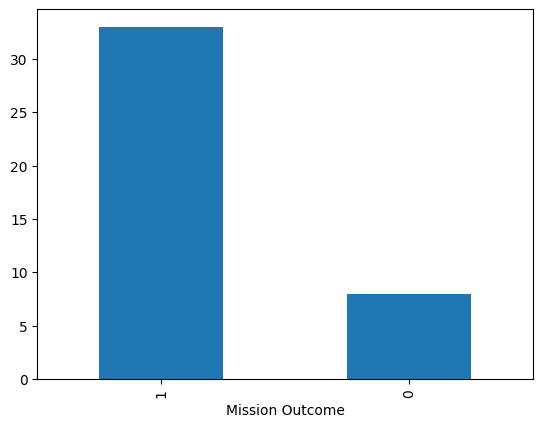

In [11]:
df["Mission Outcome"].value_counts().plot(kind="bar")
plt.show()

Heatmap

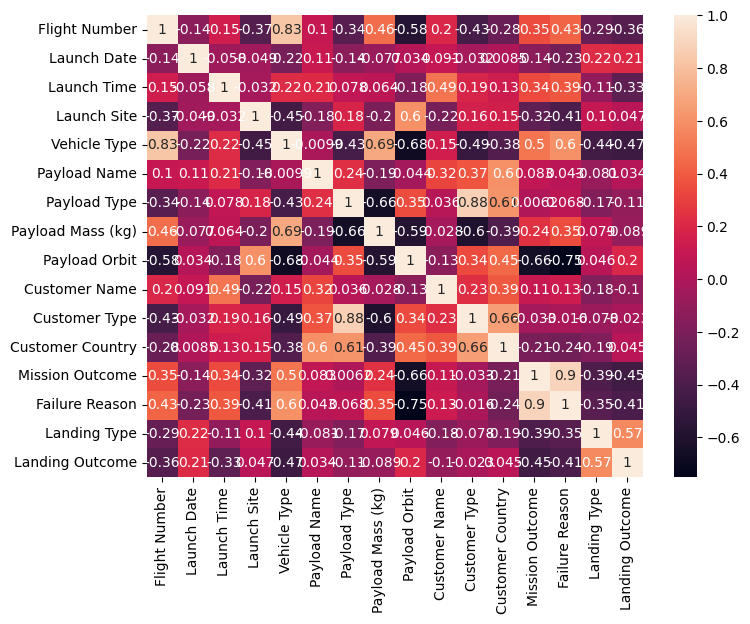

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

Classification

In [13]:
X = df.drop("Mission Outcome", axis=1)
y = df["Mission Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.8888888888888888


Headline

In [14]:
X = df.drop("Mission Outcome", axis=1)
y = df["Mission Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.7777777777777778


Feature importance

In [15]:
df = pd.get_dummies(df, columns=[
    "Launch Site",
    "Vehicle Type",
    "Payload Type",
    "Payload Orbit",
    "Customer Type",
    "Customer Country"
])